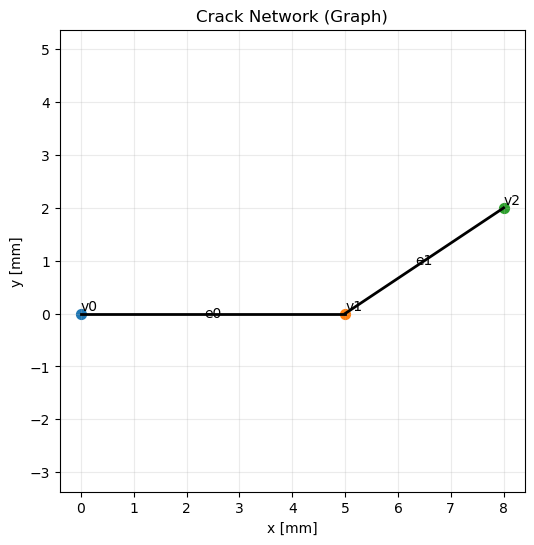

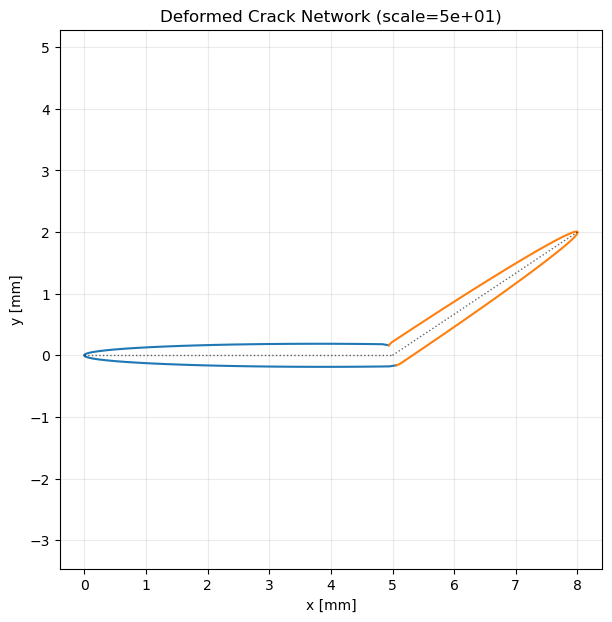

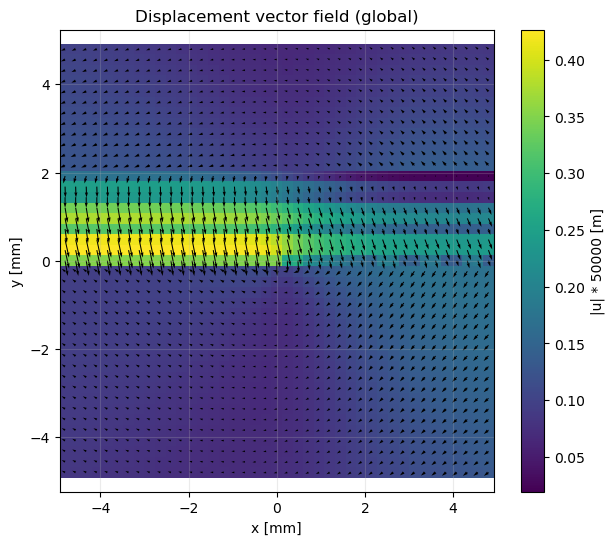

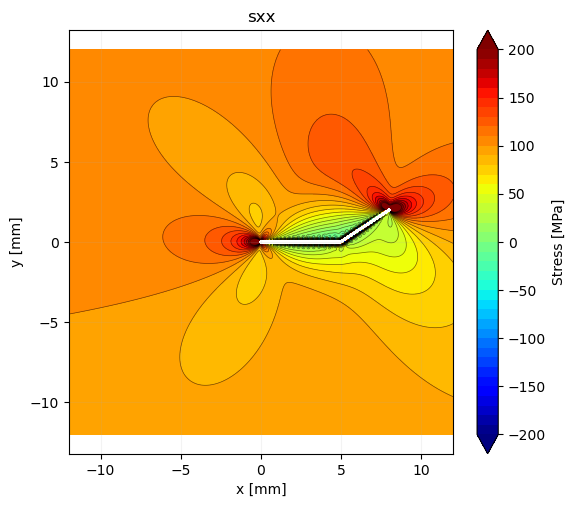

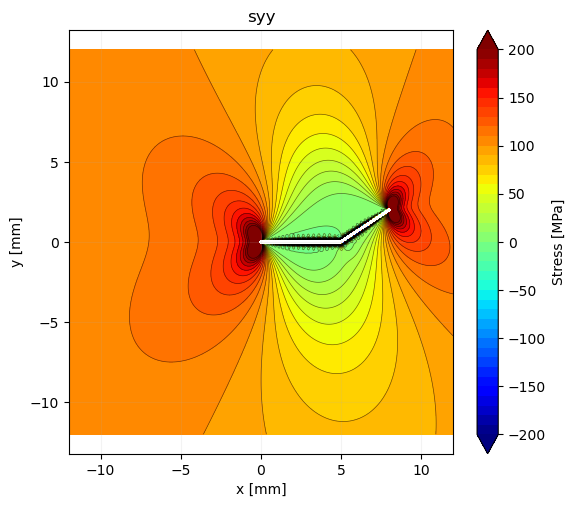

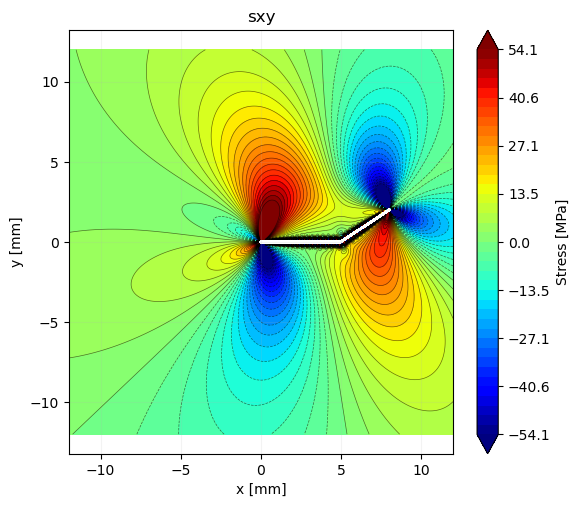

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils_half
utils_half.reload_all()
from utils_half import *
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   8.0*mm, 2.0*mm], # v2 lower-right
    # [3,   5.0*mm, -4.0*mm], # v3 upper-left
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    # [1, 3],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="full",
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




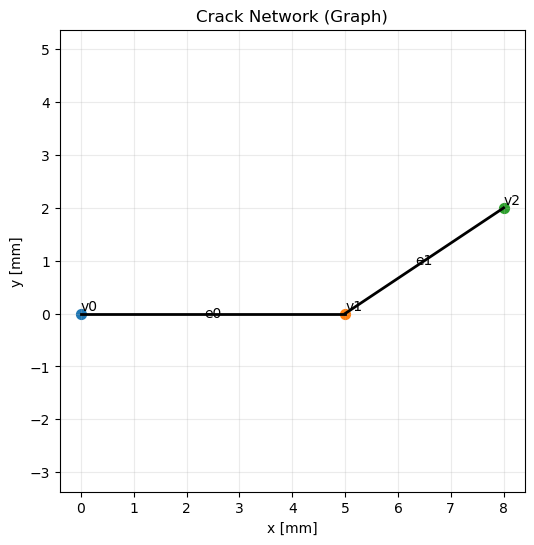

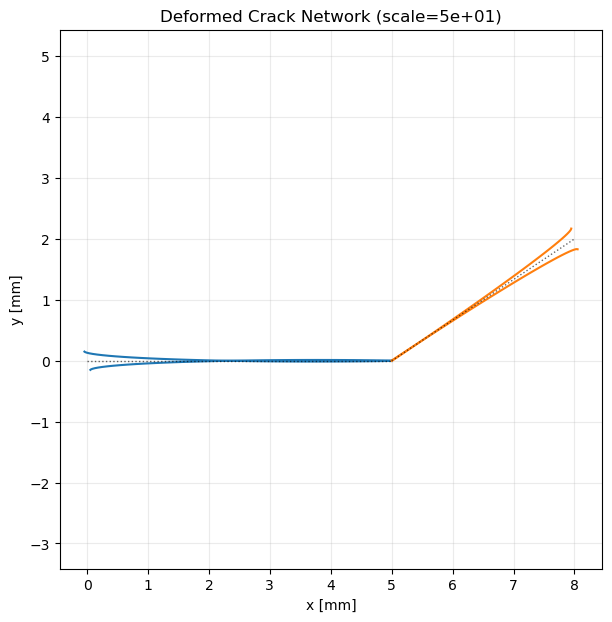

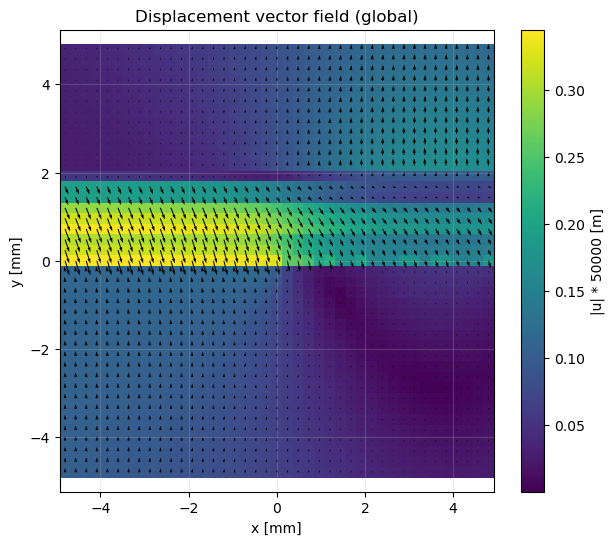

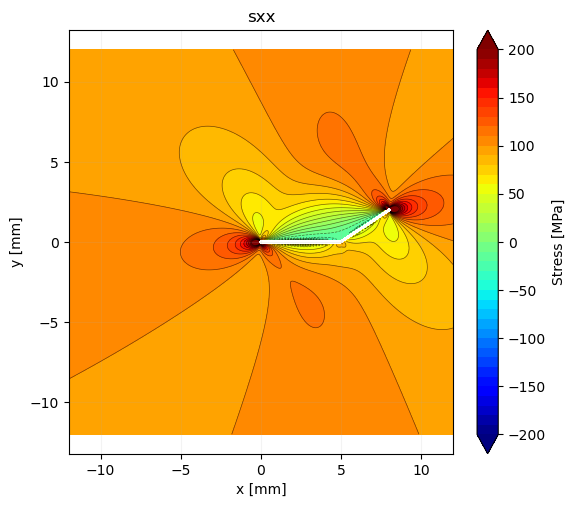

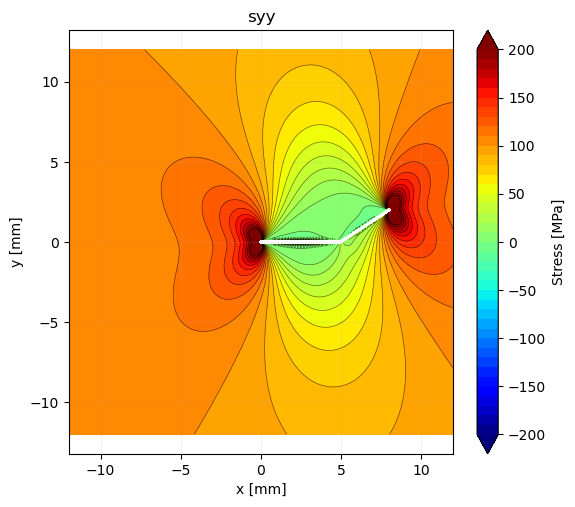

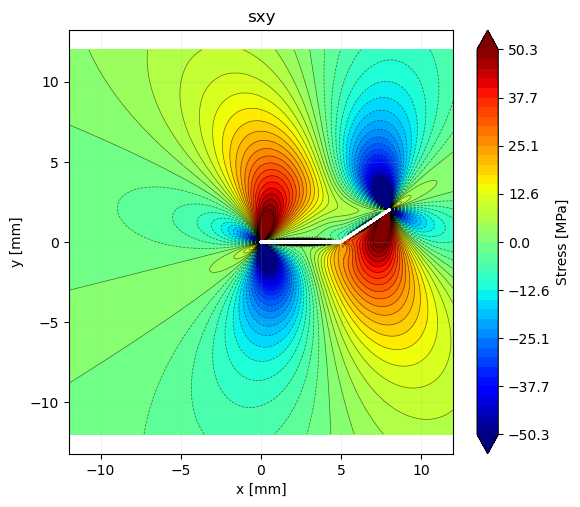

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils_half
utils_half.reload_all()
from utils_half import *
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   8.0*mm, 2.0*mm], # v2 lower-right
    # [3,   5.0*mm, -4.0*mm], # v3 upper-left
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    # [1, 3],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




In [2]:

# -------------------------
# Kink projected closure check (degree-2)
# -------------------------
import numpy as np

# -------------------------
# Build v_inc locally (vertex -> incident (pid, start/end))
# -------------------------
e2p   = sol["parametrized_edge_to_polyline"]
polys = sol["parametrized_polylines"]
solps = sol["polyline_solutions"]

v_inc = {}
for ei, pid in e2p.items():
    pid = int(pid)
    meta = polys[pid]
    v_start = int(meta.get("v_start", meta["path_vertex_ids"][0]))
    v_end   = int(meta.get("v_end",   meta["path_vertex_ids"][-1]))
    v_inc.setdefault(v_start, []).append((pid, "start"))
    v_inc.setdefault(v_end,   []).append((pid, "end"))

def outgoing_tangent(pid, which):
    s = solps[pid]
    t = np.asarray(s.get("t_mid", s.get("t_col")), float)
    tt = (+t[0]) if which == "start" else (-t[-1])
    nrm = np.linalg.norm(tt)
    return tt / nrm if nrm > 0 else np.array([1.0, 0.0])

def B_of_branch(pid):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)
    B = np.zeros(2)
    for k in range(len(ds)):
        B += (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return B

# -------------------------
# Kink projected closure check (degree-2)
# -------------------------
vk = 1  # kink vertex id

items = v_inc.get(vk, [])
print("\n--- Kink projected closure check ---")
print("vk =", vk, "incident items =", items)

if len(items) != 2:
    print("ERROR: expected exactly 2 incident branches at kink.")
else:
    (pid0, w0), (pid1, w1) = items[0], items[1]
    t0 = outgoing_tangent(pid0, w0)
    t1 = outgoing_tangent(pid1, w1)

    b = t0 + t1
    nb = np.linalg.norm(b)
    if nb <= 0:
        print("ERROR: bisector undefined (t0 ~ -t1).")
    else:
        b /= nb
        n_bis = np.array([-b[1], b[0]])  # bisector normal (CCW)

        B0 = B_of_branch(pid0)
        B1 = B_of_branch(pid1)
        Bsum = B0 + B1

        print(f"pid0={pid0} ({w0})  B0={B0}")
        print(f"pid1={pid1} ({w1})  B1={B1}")
        print("Bsum =", Bsum, " |Bsum| =", float(np.linalg.norm(Bsum)))
        print("n_bis =", n_bis)
        print("n_bis · Bsum =", float(n_bis @ Bsum))



--- Kink projected closure check ---
vk = 1 incident items = [(0, 'start'), (1, 'start')]
pid0=0 (start)  B0=[ 2.00121869e-06 -6.37909680e-06]
pid1=1 (start)  B1=[-2.19283850e-06  7.01197404e-06]
Bsum = [-1.91619809e-07  6.32877236e-07]  |Bsum| = 6.612501395256865e-07
n_bis = [-0.95709203 -0.28978415]
n_bis · Bsum = -5.01602323452156e-20


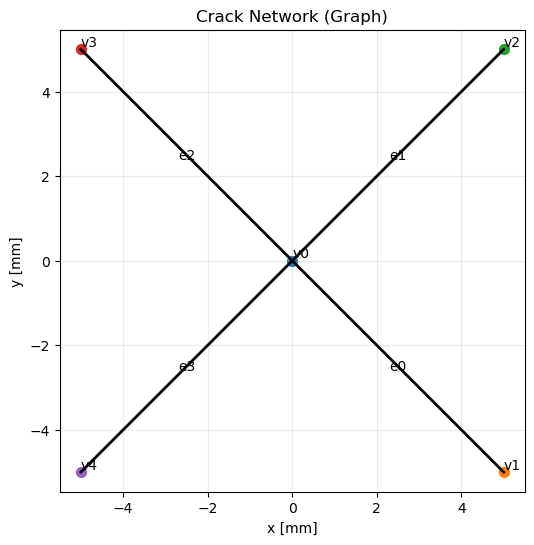

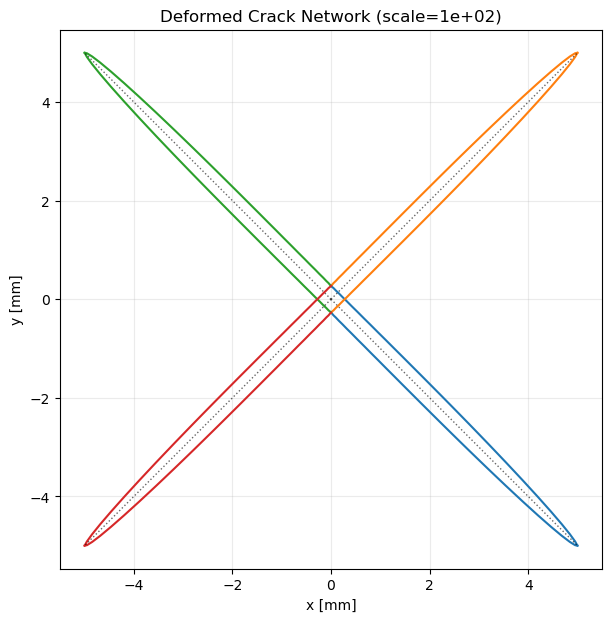

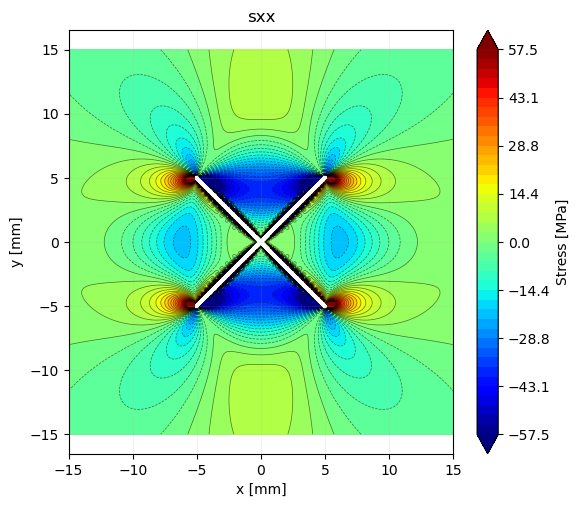

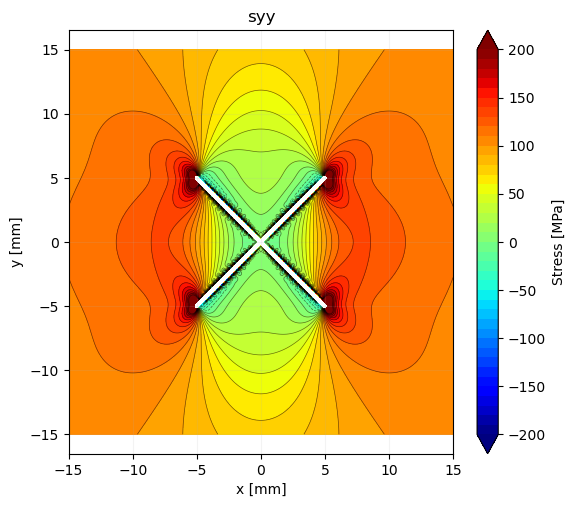

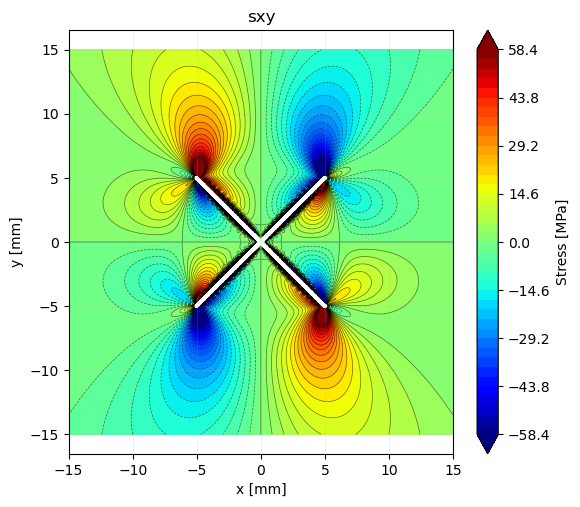

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys

nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils_half
utils_half.reload_all()
from utils_half import *

mm = 1e-3
vertices = np.array([
    [0,  0.0*mm,  0.0*mm],   # junction
    [1,  5.0*mm, - 5.0*mm],   # left tip
    [2, 5.0*mm,  5.0*mm],   # upper tip
    [3, -5.0*mm, 5.0*mm],
    [4, -5.0*mm, -5.0*mm], 
    # [5, 5.0*mm, 6.0*mm], 
    # [6, 2.0*mm, 6.0*mm],   # lower tip
    ], dtype=float)

connectivity = np.array([[0,1],[0,2],[0,3],[0,4]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=4, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

plotter = DCEPlotterV4(res, out_dir=out_dir)

plotter.plot_network_graph()
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=2000, show_faces=True, cod_smooth_window=5)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)



In [6]:

print("\n=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===")

# ---- convenience handles from solution dict ----
e2p    = sol["parametrized_edge_to_polyline"]
polys  = sol["parametrized_polylines"]
solps  = sol["polyline_solutions"]

# ---- compute vertex degrees from edges (no VertexV4.degree needed) ----
deg = {int(v.id): 0 for v in calc.network.vertices}
for e in calc.network.edges:
    deg[int(e.v0)] = deg.get(int(e.v0), 0) + 1
    deg[int(e.v1)] = deg.get(int(e.v1), 0) + 1

# ---- build vertex -> incident (pid, which_end) map ----
v_inc = {}
for ei, pid in e2p.items():
    pid = int(pid)
    pmeta = polys[pid]
    v0 = int(pmeta.get("v_start", pmeta["path_vertex_ids"][0]))
    v1 = int(pmeta.get("v_end",   pmeta["path_vertex_ids"][-1]))
    v_inc.setdefault(v0, []).append((pid, "start"))
    v_inc.setdefault(v1, []).append((pid, "end"))

# ---- helpers ----
def outgoing_tangent(pid, which):
    s = solps[pid]
    t = np.asarray(s.get("t_mid", s.get("t_col")), float)
    if which == "start":
        return +t[0]
    else:
        return -t[-1]

def B_of_branch(pid):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    B = np.zeros(2)
    for k in range(len(ds)):
        B += (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return B

def J_at_vertex(pid, which):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    J0 = np.asarray(s.get("J0", [0.0, 0.0]), float)
    J = J0.copy()

    if which == "end":
        for k in range(len(ds)):
            J -= (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return J

# ---- diagnostics per junction ----
for v, items in v_inc.items():
    dv = deg.get(int(v), 0)
    if dv < 2:
        continue

    print(f"\n--- Vertex v={v} (degree={dv}) ---")
    print("Incident branches (pid, end):", items)

    # J continuity
    Js = []
    for (pid, which) in items:
        Jv = J_at_vertex(pid, which)
        Js.append(Jv)
        print(f"  pid {pid:2d}  J(v) = {Jv}")

    J_ref = Js[0]
    for j, Jv in enumerate(Js[1:], start=1):
        print(f"  |J[{j}] - J[0]| = {np.linalg.norm(Jv - J_ref):.3e}")

    # Burgers content
    Bs = []
    for (pid, _) in items:
        Bj = B_of_branch(pid)
        Bs.append(Bj)
        print(f"  pid {pid:2d}  B = {Bj}")

    Bsum = np.sum(Bs, axis=0)
    print("  Sum B =", Bsum, " |norm| =", np.linalg.norm(Bsum))

    # Option B projected neutrality check (only for dv >= 3)
    if dv >= 3:
        g = np.zeros(2)
        for (pid, which) in items:
            g += outgoing_tangent(pid, which)

        ng = np.linalg.norm(g)
        if ng > 0:
            g /= ng
            proj = np.array([-g[1], g[0]])
            r = float(proj @ Bsum)
            print("  Projection direction p =", proj)
            print("  p · Sum B =", r)
        else:
            print("  WARNING: could not form projection direction (ng=0)")
            
            print("\n--- Tip jump check (Option A sanity) ---")
for pid, meta in enumerate(sol["parametrized_polylines"]):
    vids = meta["path_vertex_ids"]
    v_start, v_end = int(vids[0]), int(vids[-1])
    # start is junction end, end is tip end in your convention
    J_start = J_at_vertex(pid, "start")
    J_end   = J_at_vertex(pid, "end")
    print(f"pid {pid}: v_start={v_start} (deg={deg[v_start]}), v_end={v_end} (deg={deg[v_end]})")
    print(f"   J(start)={J_start},  J(end/tip)={J_end}")


print("\n=== END JUNCTION DIAGNOSTICS ===")


# common J at the junction from your diagnostic (or recompute from solps)
Jv = np.array([-1.14324090e-06, -1.02223602e-05])  # example

# outgoing unit tangents at junction (use your diagnostic helper)
def unit(v):
    n = np.linalg.norm(v)
    return v/n if n>0 else v

for (pid, which) in [(0,"start"), (1,"start"), (2,"start")]:
    t = outgoing_tangent(pid, which)          # from your diagnostic snippet
    t = unit(t)
    n = np.array([-t[1], t[0]])               # CCW normal
    COD = float(Jv @ n)
    CSD = float(Jv @ t)
    print(f"pid {pid}: COD(v0)={COD:.3e}  CSD(v0)={CSD:.3e}")
    
import numpy as np

def tip_jump_from_reconstruction(res, edge_index):
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    ex = np.asarray(extra["ex"], float)
    ey = np.asarray(extra["ey"], float)

    COD_tip = float(COD[-1])
    CSD_tip = float(CSD[-1])

    J_tip = ex * CSD_tip + ey * COD_tip
    return COD_tip, CSD_tip, J_tip

for ei in [0, 1, 2]:
    COD_tip, CSD_tip, J_tip = tip_jump_from_reconstruction(res, ei)
    print(f"edge {ei}: COD_tip={COD_tip:+.3e}  CSD_tip={CSD_tip:+.3e}  J_tip={J_tip}")


=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===

--- Vertex v=0 (degree=4) ---
Incident branches (pid, end): [(0, 'start'), (1, 'start'), (2, 'start'), (3, 'start')]
  pid  0  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  pid  1  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  pid  2  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  pid  3  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  |J[1] - J[0]| = 0.000e+00
  |J[2] - J[0]| = 0.000e+00
  |J[3] - J[0]| = 0.000e+00
  pid  0  B = [ 1.19603854e-06 -1.17613249e-05]
  pid  1  B = [1.56012333e-06 4.91057122e-06]
  pid  2  B = [5.54243781e-06 8.25095461e-06]
  pid  3  B = [-8.29859969e-06 -1.40020096e-06]
  Sum B = [-4.91279109e-20  1.40607469e-19]  |norm| = 1.4894298251567528e-19
  Projection direction p = [0.92387953 0.38268343]
  p · Sum B = 8.419877553348864e-21
pid 0: v_start=0 (deg=4), v_end=1 (deg=1)
   J(start)=[ 1.19603854e-06 -1.17613249e-05],  J(end/tip)=[1.41083925e-20 1.27054942e-21]
pid 1: v_start=0 (deg=4), v_end=2 (deg=1)
   

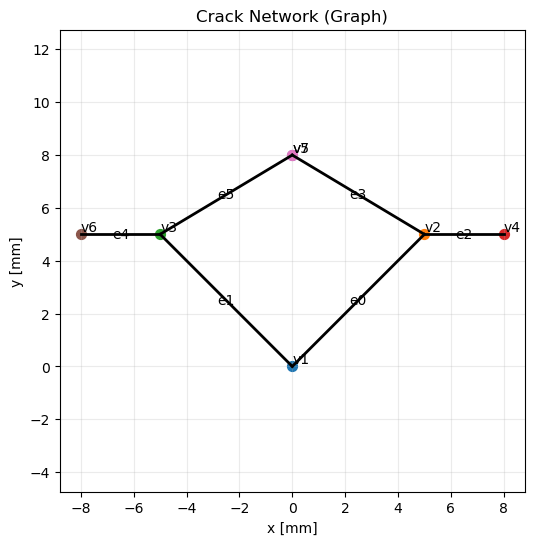

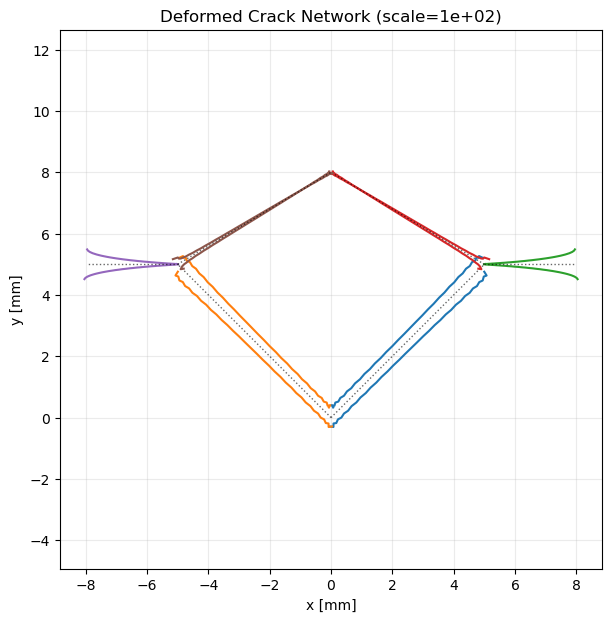

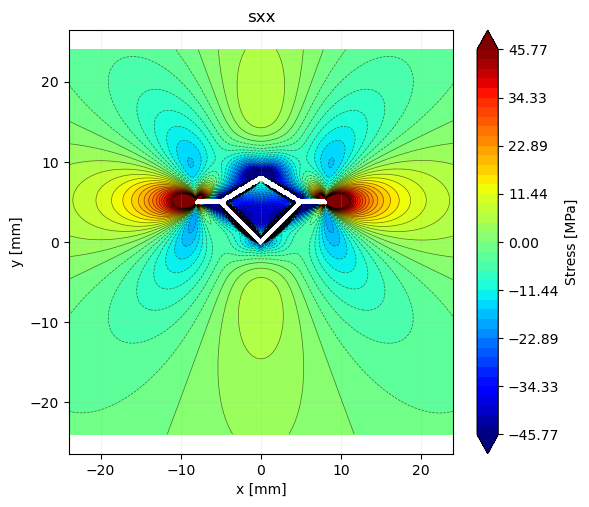

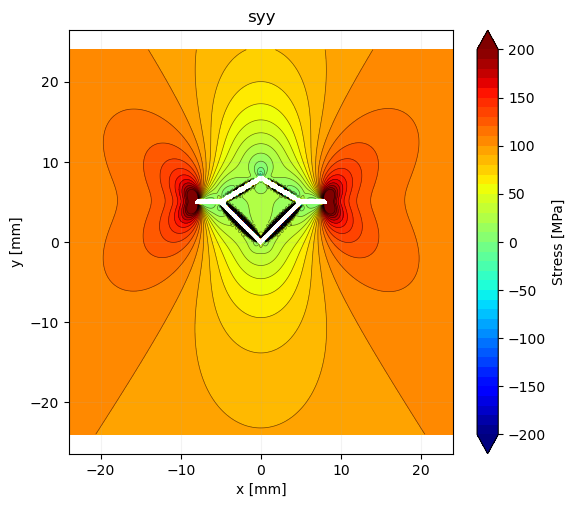

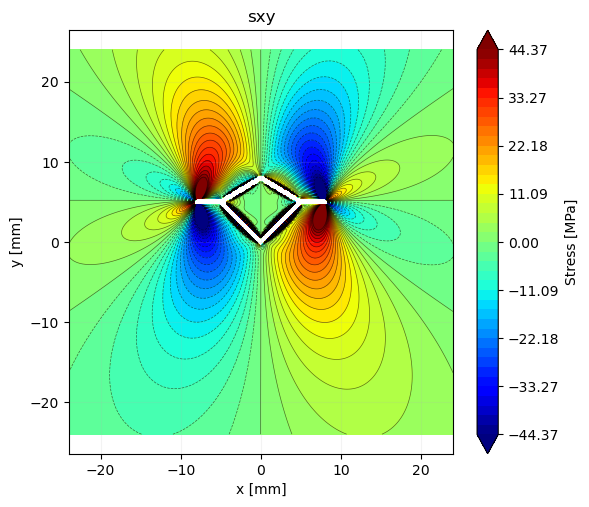

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys

nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils_half
utils_half.reload_all()

from utils_half import *

mm = 1e-3
vertices = np.array([
    [1,  0.0*mm,  0.0*mm],   
    [2,  5.0*mm,  5.0*mm],   
    [3, -5.0*mm,  5.0*mm],   
    [4, 8.0*mm, 5.0*mm],
    [5, 0.0*mm, 8.0*mm],
    [6, -8.0*mm, 5.0*mm],
    [7, 0.0*mm, 8.0*mm],  
], dtype=float)

connectivity = np.array([[1,2],[1,3],[2,4],[2,5],[3,6],[3,7]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=4, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

plotter = DCEPlotterV4(res, out_dir=out_dir)

plotter.plot_network_graph()
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=2000, show_faces=True, cod_smooth_window=5)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




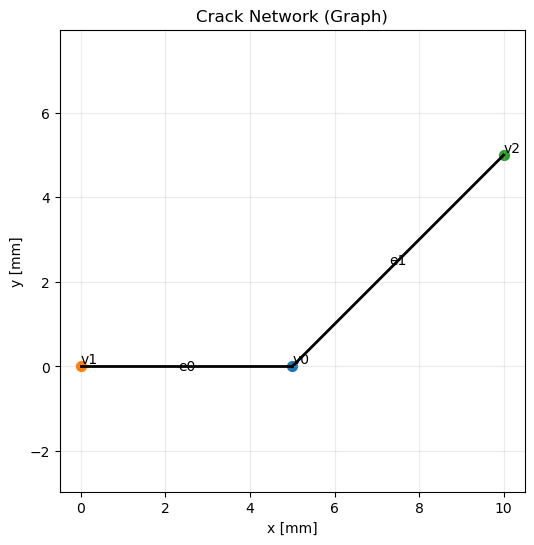

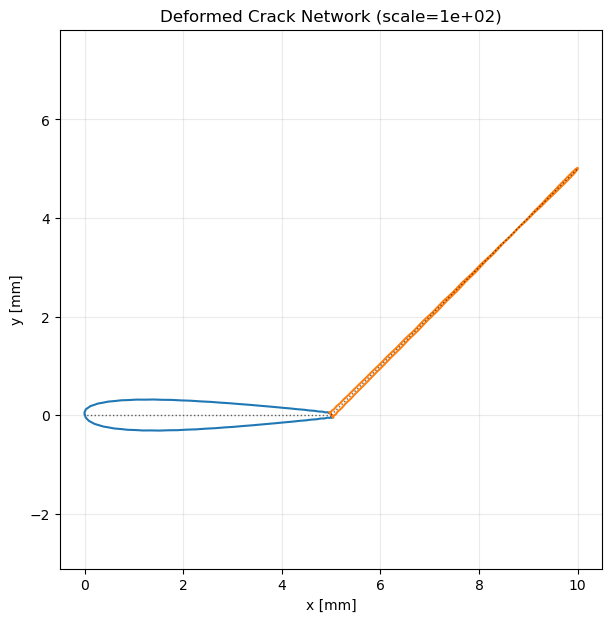

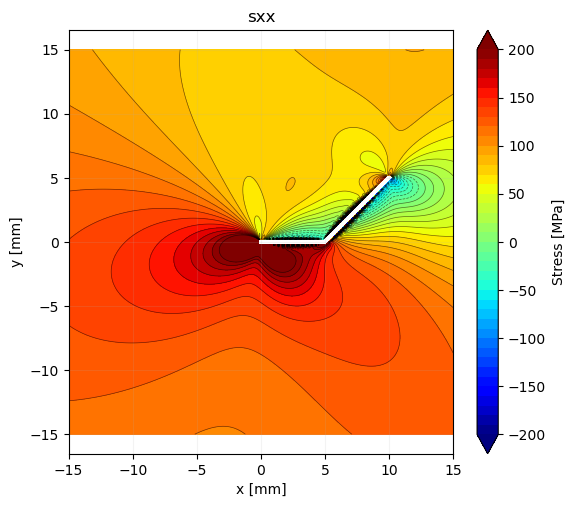

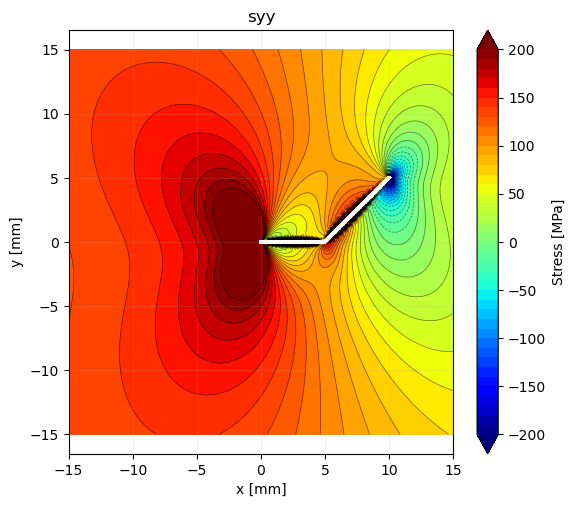

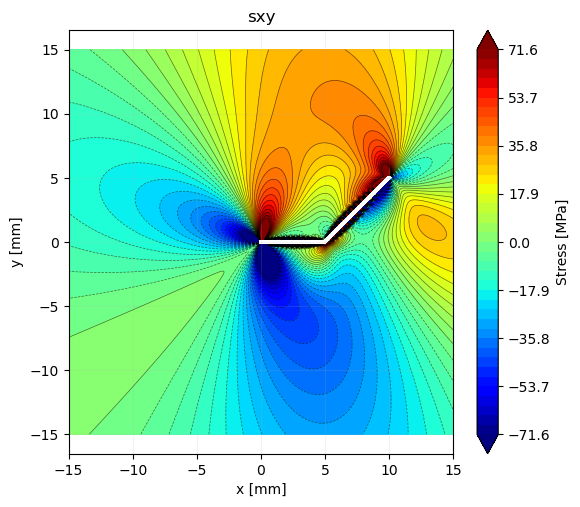

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half

=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===

--- Vertex v=0 (degree=2) ---
Incident branches (pid, end): [(0, 'start'), (1, 'start')]
  pid  0  J(v) = [ 6.74879092e-06 -1.62930226e-05]
  pid  1  J(v) = [ 6.74879092e-06 -1.62930226e-05]
  |J[1] - J[0]| = 0.000e+00
  pid  0  B = [ 6.74879092e-06 -1.62930226e-05]
  pid  1  B = [ 6.74879092e-06 -1.62930226e-05]
  Sum B = [ 1.34975818e-05 -3.25860452e-05]  |norm| = 3.527088111690949e-05
pid 0: v_start=0 (deg=2), v_end=1 (deg=1)
   J(start)=[ 6.74879092e-06 -1.62930226e-05],  J(end/tip)=[-8.80914265e-20 -1.38913403e-19]
pid 1: v_start=0 (deg=2), v_end=2 (deg=1)
   J(start)=[ 6.74879092e-06 -1.62930226e-05],  J(end/tip)=[ 6.63332677e-20 -2.36639830e-19]

=== END JUNCTION DIAGNOSTICS ===
pid 0: COD(v0)=1.022e-05  CSD(v0)=1.143e-06
pid 1: COD(v0)=-6.420e-06  CSD(v0)=-8.037e-06


IndexError: list index out of range

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys

nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils_half
utils_half.reload_all()
from utils_half import *
#from utils import CrackNetworkV4, Material, AppliedStress
# from utils_half import DCENetworkStaticV4, DCEResultsNetworkV4
# from utils_half.plotter import DCEPlotterV4, StressPlotOptsV4  # adjust if your facade exports these

mm = 1e-3
vertices = np.array([
    [0,  5.0*mm,  0.0*mm],   # junction
    [1,  0.0*mm,  0.0*mm],   # left tip
    [2, 10.0*mm,  5.0*mm],   # upper tip
], dtype=float)

connectivity = np.array([[0,1],[0,2]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=4, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

plotter = DCEPlotterV4(res, out_dir=out_dir)

plotter.plot_network_graph()
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=2000, show_faces=True, cod_smooth_window=5)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


print("\n=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===")

# ---- convenience handles from solution dict ----
e2p    = sol["parametrized_edge_to_polyline"]
polys  = sol["parametrized_polylines"]
solps  = sol["polyline_solutions"]

# ---- compute vertex degrees from edges (no VertexV4.degree needed) ----
deg = {int(v.id): 0 for v in calc.network.vertices}
for e in calc.network.edges:
    deg[int(e.v0)] = deg.get(int(e.v0), 0) + 1
    deg[int(e.v1)] = deg.get(int(e.v1), 0) + 1

# ---- build vertex -> incident (pid, which_end) map ----
v_inc = {}
for ei, pid in e2p.items():
    pid = int(pid)
    pmeta = polys[pid]
    v0 = int(pmeta.get("v_start", pmeta["path_vertex_ids"][0]))
    v1 = int(pmeta.get("v_end",   pmeta["path_vertex_ids"][-1]))
    v_inc.setdefault(v0, []).append((pid, "start"))
    v_inc.setdefault(v1, []).append((pid, "end"))

# ---- helpers ----
def outgoing_tangent(pid, which):
    s = solps[pid]
    t = np.asarray(s.get("t_mid", s.get("t_col")), float)
    if which == "start":
        return +t[0]
    else:
        return -t[-1]

def B_of_branch(pid):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    B = np.zeros(2)
    for k in range(len(ds)):
        B += (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return B

def J_at_vertex(pid, which):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    J0 = np.asarray(s.get("J0", [0.0, 0.0]), float)
    J = J0.copy()

    if which == "end":
        for k in range(len(ds)):
            J -= (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return J

# ---- diagnostics per junction ----
for v, items in v_inc.items():
    dv = deg.get(int(v), 0)
    if dv < 2:
        continue

    print(f"\n--- Vertex v={v} (degree={dv}) ---")
    print("Incident branches (pid, end):", items)

    # J continuity
    Js = []
    for (pid, which) in items:
        Jv = J_at_vertex(pid, which)
        Js.append(Jv)
        print(f"  pid {pid:2d}  J(v) = {Jv}")

    J_ref = Js[0]
    for j, Jv in enumerate(Js[1:], start=1):
        print(f"  |J[{j}] - J[0]| = {np.linalg.norm(Jv - J_ref):.3e}")

    # Burgers content
    Bs = []
    for (pid, _) in items:
        Bj = B_of_branch(pid)
        Bs.append(Bj)
        print(f"  pid {pid:2d}  B = {Bj}")

    Bsum = np.sum(Bs, axis=0)
    print("  Sum B =", Bsum, " |norm| =", np.linalg.norm(Bsum))

    # Option B projected neutrality check (only for dv >= 3)
    if dv >= 3:
        g = np.zeros(2)
        for (pid, which) in items:
            g += outgoing_tangent(pid, which)

        ng = np.linalg.norm(g)
        if ng > 0:
            g /= ng
            proj = np.array([-g[1], g[0]])
            r = float(proj @ Bsum)
            print("  Projection direction p =", proj)
            print("  p · Sum B =", r)
        else:
            print("  WARNING: could not form projection direction (ng=0)")
            
            print("\n--- Tip jump check (Option A sanity) ---")
for pid, meta in enumerate(sol["parametrized_polylines"]):
    vids = meta["path_vertex_ids"]
    v_start, v_end = int(vids[0]), int(vids[-1])
    # start is junction end, end is tip end in your convention
    J_start = J_at_vertex(pid, "start")
    J_end   = J_at_vertex(pid, "end")
    print(f"pid {pid}: v_start={v_start} (deg={deg[v_start]}), v_end={v_end} (deg={deg[v_end]})")
    print(f"   J(start)={J_start},  J(end/tip)={J_end}")


print("\n=== END JUNCTION DIAGNOSTICS ===")


# common J at the junction from your diagnostic (or recompute from solps)
Jv = np.array([-1.14324090e-06, -1.02223602e-05])  # example

# outgoing unit tangents at junction (use your diagnostic helper)
def unit(v):
    n = np.linalg.norm(v)
    return v/n if n>0 else v

for (pid, which) in [(0,"start"), (1,"start"), (2,"start")]:
    t = outgoing_tangent(pid, which)          # from your diagnostic snippet
    t = unit(t)
    n = np.array([-t[1], t[0]])               # CCW normal
    COD = float(Jv @ n)
    CSD = float(Jv @ t)
    print(f"pid {pid}: COD(v0)={COD:.3e}  CSD(v0)={CSD:.3e}")
    
import numpy as np

def tip_jump_from_reconstruction(res, edge_index):
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    ex = np.asarray(extra["ex"], float)
    ey = np.asarray(extra["ey"], float)

    COD_tip = float(COD[-1])
    CSD_tip = float(CSD[-1])

    J_tip = ex * CSD_tip + ey * COD_tip
    return COD_tip, CSD_tip, J_tip

for ei in [0, 1, 2]:
    COD_tip, CSD_tip, J_tip = tip_jump_from_reconstruction(res, ei)
    print(f"edge {ei}: COD_tip={COD_tip:+.3e}  CSD_tip={CSD_tip:+.3e}  J_tip={J_tip}")


